Name: Prakhar Tyagi 
URN : 2481010 
section: b 
lab Subject : Introduction to Machine learning 
Experiment 1 

In [2]:
print("Name: Prakhar Tyagi")
print("URN: 2481010")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42


Name: Prakhar Tyagi
URN: 2481010


In [3]:
print("Name: Prakhar Tyagi")
print("URN: 2481010")

df = pd.read_csv('ecommerce_delivery_predictions.csv')
print('Shape:', df.shape)
df.head()


Name: Prakhar Tyagi
URN: 2481010
Shape: (100000, 40)


,customer_id,customer_age,customer_gender,customer_city,customer_state,customer_income,customer_rating,order_id,order_date,product_category,product_price,quantity,discount_percent,order_value,payment_method,order_priority,seller_id,seller_rating,seller_experience_years,seller_city,seller_reliability_score,warehouse_distance_km,shipping_method,carrier,package_weight_kg,package_volume,processing_time_hours,dispatch_delay_hours,estimated_delivery_days,weather_condition,traffic_level,holiday_period,weekend_order,peak_season,distance_to_delivery_ratio,shipping_risk_score,seller_performance_score,customer_order_frequency,delivery_efficiency_score,late_delivery
0,CUST-25795,45,Male,Los Angeles,CA,42718.80,2.9,ORD-100000,2025-04-08,Clothing,137.54,1,0,137.54,Debit Card,Medium,SELL-5840,3.7,7,Houston,74.4,400.7,Same-Day,OnTrac,2.66,677.3,2.1,2.3,1,Clear,Low,0,0,0,400.70,3.4,74.3,3,97.3,0
1,CUST-10860,29,Male,San Diego,CA,52107.35,2.7,ORD-100001,2025-10-22,Books,40.42,1,0,40.42,Debit Card,High,SELL-2443,3.7,14,Houston,87.6,108.7,Standard,UPS,1.74,364.6,3.7,0.8,5,Clear,Low,0,0,1,21.74,1.2,83.5,2,97.5,1
2,CUST-86820,59,Male,Dallas,TX,38894.75,4.9,ORD-100002,2025-10-03,Automotive,104.94,3,25,236.12,Debit Card,Medium,SELL-4102,2.7,14,Phoenix,62.3,346.0,Standard,OnTrac,0.18,74.4,34.5,3.7,5,Fog,Medium,0,0,1,69.20,3.0,59.8,5,79.5,0
3,CUST-64886,47,Female,San Diego,CA,74470.09,4.0,ORD-100003,2025-01-22,Toys,5.00,3,5,14.25,Credit Card,Medium,SELL-4137,3.4,4,San Antonio,66.0,237.6,Standard,USPS,2.88,895.1,9.4,8.0,5,Storm,Low,0,0,0,47.52,19.5,66.6,3,89.5,1
4,CUST-16265,36,Female,Dallas,TX,33903.35,1.5,ORD-100004,2025-01-08,Books,130.79,2,0,261.58,Debit Card,High,SELL-6379,4.6,2,Houston,85.9,239.8,Express,UPS,3.68,1045.4,14.8,5.7,2,Rain,Low,0,0,0,119.90,4.0,87.7,2,88.3,0


In [4]:
print("Name: Prakhar Tyagi")
print("URN: 2481010")
# 2. Select inputs and target
drop_cols = ['customer_id', 'order_id', 'seller_id', 'order_date']
target = 'late_delivery'

X = df.drop(columns=drop_cols + [target])
y = df[target]

print('X shape:', X.shape)
print('Features:', X.columns.tolist())


Name: Prakhar Tyagi
URN: 2481010
X shape: (100000, 35)
Features: ['customer_age', 'customer_gender', 'customer_city', 'customer_state', 'customer_income', 'customer_rating', 'product_category', 'product_price', 'quantity', 'discount_percent', 'order_value', 'payment_method', 'order_priority', 'seller_rating', 'seller_experience_years', 'seller_city', 'seller_reliability_score', 'warehouse_distance_km', 'shipping_method', 'carrier', 'package_weight_kg', 'package_volume', 'processing_time_hours', 'dispatch_delay_hours', 'estimated_delivery_days', 'weather_condition', 'traffic_level', 'holiday_period', 'weekend_order', 'peak_season', 'distance_to_delivery_ratio', 'shipping_risk_score', 'seller_performance_score', 'customer_order_frequency', 'delivery_efficiency_score']


Name: Prakhar Tyagi
URN: 2481010
               count    pct
late_delivery              
0              76684  76.68
1              23316  23.32


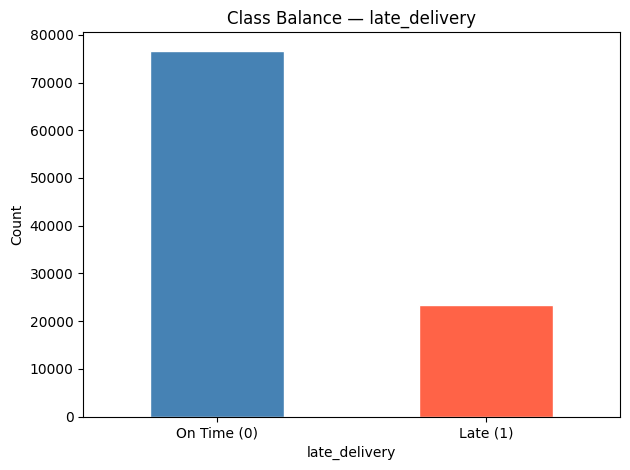

In [5]:
print("Name: Prakhar Tyagi")
print("URN: 2481010")
# 3. Class balance
counts = y.value_counts()
pct = y.value_counts(normalize=True) * 100

print(pd.DataFrame({'count': counts, 'pct': pct.round(2)}))

counts.plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='white')
plt.title('Class Balance — late_delivery')
plt.xticks([0, 1], ['On Time (0)', 'Late (1)'], rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.show()


In [6]:
print("Name: Prakhar Tyagi")
print("URN: 2481010")
# 4. Train/test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')
print('\nTrain distribution:\n', y_train.value_counts(normalize=True).round(3))
print('\nTest distribution:\n', y_test.value_counts(normalize=True).round(3))


Name: Prakhar Tyagi
URN: 2481010
Train: 80000 | Test: 20000

Train distribution:
 late_delivery
0    0.767
1    0.233
Name: proportion, dtype: float64

Test distribution:
 late_delivery
0    0.767
1    0.233
Name: proportion, dtype: float64


In [7]:
print("Name: Prakhar Tyagi")
print("URN: 2481010")
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer

# Identify column types
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

print('Numerical:', num_cols)
print('Categorical:', cat_cols)


Name: Prakhar Tyagi
URN: 2481010
Numerical: ['customer_age', 'customer_income', 'customer_rating', 'product_price', 'quantity', 'discount_percent', 'order_value', 'seller_rating', 'seller_experience_years', 'seller_reliability_score', 'warehouse_distance_km', 'package_weight_kg', 'package_volume', 'processing_time_hours', 'dispatch_delay_hours', 'estimated_delivery_days', 'holiday_period', 'weekend_order', 'peak_season', 'distance_to_delivery_ratio', 'shipping_risk_score', 'seller_performance_score', 'customer_order_frequency', 'delivery_efficiency_score']
Categorical: ['customer_gender', 'customer_city', 'customer_state', 'product_category', 'payment_method', 'order_priority', 'seller_city', 'shipping_method', 'carrier', 'weather_condition', 'traffic_level']


In [8]:
print("Name: Prakhar Tyagi")
print("URN: 2481010")
# Numeric transformer: impute missing → scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical transformer: impute missing → one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine into a ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
])


Name: Prakhar Tyagi
URN: 2481010


In [9]:
print("Name: Prakhar Tyagi")
print("URN: 2481010")
# Full pipeline: preprocessor + logistic regression
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Fit ONLY on training data — test set is never seen during fitting
pipeline.fit(X_train, y_train)

print('Pipeline trained successfully.')
print('Steps:', [name for name, _ in pipeline.steps])


Name: Prakhar Tyagi
URN: 2481010
Pipeline trained successfully.
Steps: ['preprocessor', 'classifier']


In [10]:
print("Name: Prakhar Tyagi")
print("URN: 2481010")
# Class labels (0 or 1) — uses default 0.5 threshold
y_pred = pipeline.predict(X_test)

# Probabilities — column 0 = P(on time), column 1 = P(late)
y_prob = pipeline.predict_proba(X_test)

# Tidy summary
results = pd.DataFrame({
    'actual'      : y_test.values,
    'predicted'   : y_pred,
    'prob_on_time': y_prob[:, 0].round(4),
    'prob_late'   : y_prob[:, 1].round(4)
})

print(results.head(10))


Name: Prakhar Tyagi
URN: 2481010
   actual  predicted  prob_on_time  prob_late
0       1          0        0.7713     0.2287
1       0          0        0.7151     0.2849
2       0          0        0.8146     0.1854
3       0          0        0.8645     0.1355
4       0          0        0.8305     0.1695
5       0          0        0.7930     0.2070
6       1          0        0.8155     0.1845
7       0          0        0.5450     0.4550
8       0          0        0.8204     0.1796
9       0          0        0.8978     0.1022


In [11]:
print("Name: Prakhar Tyagi")
print("URN: 2481010")
# Quick sanity check — prob_late > 0.5 should match predicted == 1
assert (results['prob_late'] > 0.5).equals(results['predicted'].astype(bool)), \
    "Mismatch between probabilities and predicted labels"
print("Sanity check passed — probabilities and labels are consistent.")


Name: Prakhar Tyagi
URN: 2481010
Sanity check passed — probabilities and labels are consistent.


In [12]:
print("Name: Prakhar Tyagi")
print("URN: 2481010")
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, f1_score,
                             roc_auc_score, classification_report)

# Baseline: always predicts the majority class
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)
y_dummy = dummy.predict(X_test)


Name: Prakhar Tyagi
URN: 2481010


In [13]:
print("Name: Prakhar Tyagi")
print("URN: 2481010")
# Compare metrics side by side
metrics = {
    'Accuracy' : [accuracy_score(y_test, y_dummy),
                  accuracy_score(y_test, y_pred)],
    'F1 Score' : [f1_score(y_test, y_dummy, zero_division=0),
                  f1_score(y_test, y_pred)],
    'ROC-AUC'  : [roc_auc_score(y_test, dummy.predict_proba(X_test)[:, 1]),
                  roc_auc_score(y_test, y_prob[:, 1])]
}

comparison = pd.DataFrame(metrics, index=['Baseline (majority)', 'Logistic Regression'])
print(comparison.round(4))


Name: Prakhar Tyagi
URN: 2481010
                     Accuracy  F1 Score  ROC-AUC
Baseline (majority)    0.7668    0.0000   0.5000
Logistic Regression    0.7730    0.1706   0.6785


In [14]:
print("Name: Prakhar Tyagi")
print("URN: 2481010")
# Full classification report for logistic regression
print("\nLogistic Regression — Classification Report:")
print(classification_report(y_test, y_pred, target_names=['On Time (0)', 'Late (1)']))


Name: Prakhar Tyagi
URN: 2481010

Logistic Regression — Classification Report:
              precision    recall  f1-score   support

 On Time (0)       0.78      0.98      0.87     15337
    Late (1)       0.58      0.10      0.17      4663

    accuracy                           0.77     20000
   macro avg       0.68      0.54      0.52     20000
weighted avg       0.73      0.77      0.71     20000



Name: Prakhar Tyagi
URN: 2481010


c:\Users\prakhar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


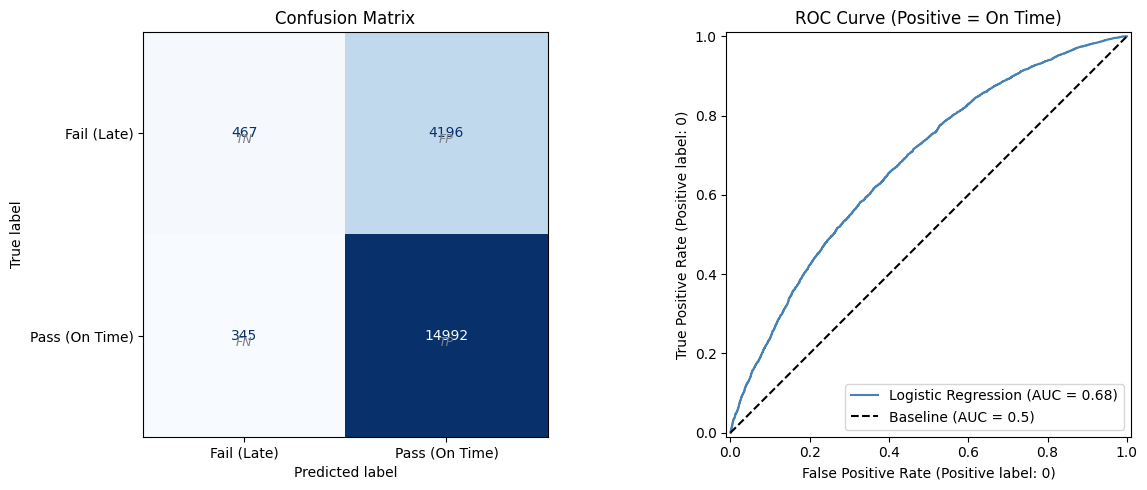

In [15]:
print("Name: Prakhar Tyagi")
print("URN: 2481010")
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

# --- Confusion Matrix ---
# pos_label=0 so "On Time" is treated as the positive class
cm = confusion_matrix(y_test, y_pred, labels=[1, 0])  # rows/cols: [Fail, Pass]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Fail (Late)', 'Pass (On Time)']
)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix')

# Annotate quadrants
axes[0].text(0, 0, 'TN', fontsize=9, ha='center', va='top',
             color='grey', style='italic')
axes[0].text(1, 0, 'FP', fontsize=9, ha='center', va='top',
             color='grey', style='italic')
axes[0].text(0, 1, 'FN', fontsize=9, ha='center', va='top',
             color='grey', style='italic')
axes[0].text(1, 1, 'TP', fontsize=9, ha='center', va='top',
             color='grey', style='italic')

# --- ROC Curve ---
# pos_label=0: On Time is positive, so we use prob_on_time (col 0)
RocCurveDisplay.from_predictions(
    y_test, y_prob[:, 0],
    pos_label=0,
    name='Logistic Regression',
    ax=axes[1],
    color='steelblue'
)
axes[1].plot([0, 1], [0, 1], 'k--', label='Baseline (AUC = 0.5)')
axes[1].set_title('ROC Curve (Positive = On Time)')
axes[1].legend()

plt.tight_layout()
plt.show()


In [16]:
print("Name: Prakhar Tyagi")
print("URN: 2481010")
import numpy as np

# Extract feature names after preprocessing
num_feature_names = num_cols
cat_feature_names = (pipeline
                     .named_steps['preprocessor']
                     .named_transformers_['cat']
                     .named_steps['encoder']
                     .get_feature_names_out(cat_cols)
                     .tolist())

all_feature_names = num_feature_names + cat_feature_names

# Extract coefficients (pos_label=0 → On Time is positive)
coefficients = pipeline.named_steps['classifier'].coef_[0]

coef_df = pd.DataFrame({
    'feature'    : all_feature_names,
    'coefficient': coefficients,
    'odds_ratio' : np.exp(coefficients)
}).sort_values('coefficient', ascending=False)

print(coef_df.to_string(index=False))


Name: Prakhar Tyagi
URN: 2481010
                        feature  coefficient  odds_ratio
       shipping_method_Same-Day     0.513573    1.671252
            shipping_risk_score     0.356422    1.428210
                 holiday_period     0.145687    1.156834
           dispatch_delay_hours     0.135253    1.144826
                    peak_season     0.133041    1.142297
        weather_condition_Storm     0.111526    1.117982
        estimated_delivery_days     0.089918    1.094085
                  seller_rating     0.082111    1.085576
          processing_time_hours     0.075650    1.078586
              traffic_level_Jam     0.057350    1.059026
     distance_to_delivery_ratio     0.034040    1.034626
                 package_volume     0.029271    1.029704
                   customer_age     0.023470    1.023747
                    order_value     0.017115    1.017263
        seller_experience_years     0.014827    1.014938
               discount_percent     0.005880    1.00589

Name: Prakhar Tyagi
URN: 2481010


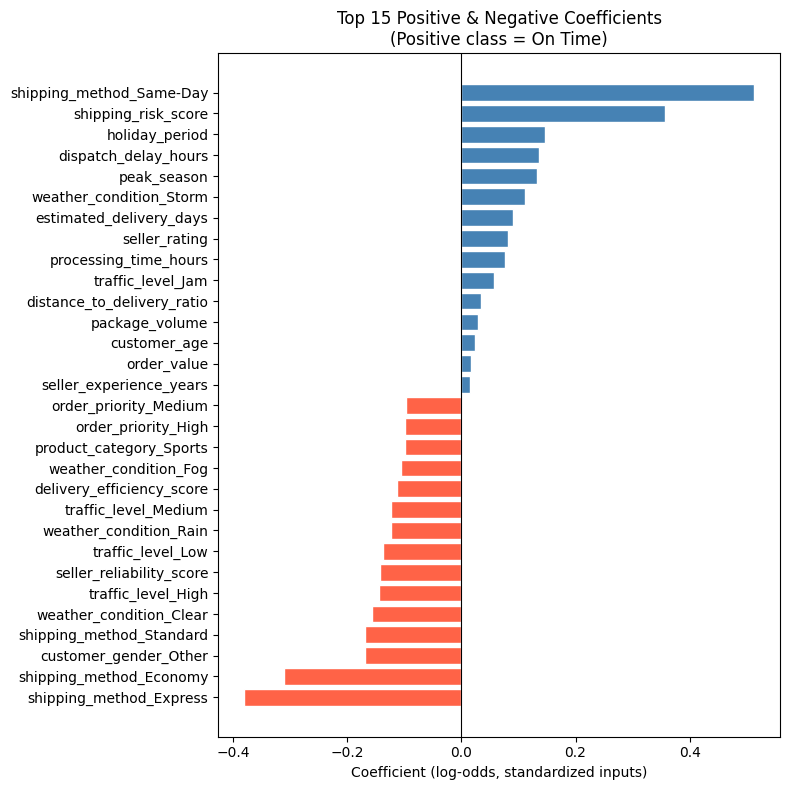

In [17]:
print("Name: Prakhar Tyagi")
print("URN: 2481010")
# Plot top 15 positive and top 15 negative coefficients
n = 15
top = pd.concat([coef_df.head(n), coef_df.tail(n)])

colors = ['steelblue' if c > 0 else 'tomato' for c in top['coefficient']]

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(top['feature'], top['coefficient'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (log-odds, standardized inputs)')
ax.set_title('Top 15 Positive & Negative Coefficients\n(Positive class = On Time)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


In [18]:
print("Name: Prakhar Tyagi")
print("URN: 2481010")
# Odds ratio table for the same top features
print("\nOdds Ratios for top features:")
print(top[['feature', 'coefficient', 'odds_ratio']].to_string(index=False))


Name: Prakhar Tyagi
URN: 2481010

Odds Ratios for top features:
                   feature  coefficient  odds_ratio
  shipping_method_Same-Day     0.513573    1.671252
       shipping_risk_score     0.356422    1.428210
            holiday_period     0.145687    1.156834
      dispatch_delay_hours     0.135253    1.144826
               peak_season     0.133041    1.142297
   weather_condition_Storm     0.111526    1.117982
   estimated_delivery_days     0.089918    1.094085
             seller_rating     0.082111    1.085576
     processing_time_hours     0.075650    1.078586
         traffic_level_Jam     0.057350    1.059026
distance_to_delivery_ratio     0.034040    1.034626
            package_volume     0.029271    1.029704
              customer_age     0.023470    1.023747
               order_value     0.017115    1.017263
   seller_experience_years     0.014827    1.014938
     order_priority_Medium    -0.097502    0.907101
       order_priority_High    -0.098314    0.906364


In [19]:
print("Name: Prakhar Tyagi")
print("URN: 2481010")
# Define new input(s) — must match the same columns as X
new_orders = pd.DataFrame([
    {
        # Customer
        'customer_age'              : 35,
        'customer_gender'           : 'Female',
        'customer_city'             : 'Los Angeles',
        'customer_state'            : 'CA',
        'customer_income'           : 65000,
        'customer_rating'           : 4.2,
        'customer_order_frequency'  : 3,

        # Product / Order
        'product_category'          : 'Electronics',
        'product_price'             : 120.0,
        'quantity'                  : 1,
        'discount_percent'          : 10,
        'order_value'               : 108.0,
        'payment_method'            : 'Credit Card',
        'order_priority'            : 'High',

        # Seller
        'seller_rating'             : 4.5,
        'seller_experience_years'   : 8,
        'seller_city'               : 'Houston',
        'seller_reliability_score'  : 90.0,
        'seller_performance_score'  : 88.0,

        # Shipping
        'warehouse_distance_km'     : 150.0,
        'shipping_method'           : 'Express',
        'carrier'                   : 'UPS',
        'package_weight_kg'         : 1.5,
        'package_volume'            : 500.0,
        'processing_time_hours'     : 3.0,
        'dispatch_delay_hours'      : 1.0,
        'estimated_delivery_days'   : 2,

        # Context
        'weather_condition'         : 'Clear',
        'traffic_level'             : 'Low',
        'holiday_period'            : 0,
        'weekend_order'             : 0,
        'peak_season'               : 0,

        # Engineered
        'distance_to_delivery_ratio': 75.0,
        'shipping_risk_score'       : 2.5,
        'delivery_efficiency_score' : 95.0,
    },
    {
        # A riskier order — long distance, bad weather, high delay
        'customer_age'              : 52,
        'customer_gender'           : 'Male',
        'customer_city'             : 'Dallas',
        'customer_state'            : 'TX',
        'customer_income'           : 38000,
        'customer_rating'           : 2.1,
        'customer_order_frequency'  : 1,

        'product_category'          : 'Furniture',
        'product_price'             : 450.0,
        'quantity'                  : 2,
        'discount_percent'          : 0,
        'order_value'               : 900.0,
        'payment_method'            : 'Debit Card',
        'order_priority'            : 'Low',

        'seller_rating'             : 2.5,
        'seller_experience_years'   : 1,
        'seller_city'               : 'Phoenix',
        'seller_reliability_score'  : 55.0,
        'seller_performance_score'  : 52.0,

        'warehouse_distance_km'     : 1200.0,
        'shipping_method'           : 'Economy',
        'carrier'                   : 'OnTrac',
        'package_weight_kg'         : 18.0,
        'package_volume'            : 3200.0,
        'processing_time_hours'     : 30.0,
        'dispatch_delay_hours'      : 20.0,
        'estimated_delivery_days'   : 7,

        'weather_condition'         : 'Storm',
        'traffic_level'             : 'Jam',
        'holiday_period'            : 1,
        'weekend_order'             : 1,
        'peak_season'               : 1,

        'distance_to_delivery_ratio': 171.4,
        'shipping_risk_score'       : 38.0,
        'delivery_efficiency_score' : 60.0,
    }
])


Name: Prakhar Tyagi
URN: 2481010


In [20]:
print("Name: Prakhar Tyagi")
print("URN: 2481010")
# Run through the same pipeline (preprocessor + model)
new_labels = pipeline.predict(new_orders)
new_probs  = pipeline.predict_proba(new_orders)

for i, (label, probs) in enumerate(zip(new_labels, new_probs)):
    outcome = 'On Time (Pass)' if label == 0 else 'Late (Fail)'
    print(f"Order {i+1}: {outcome}")
    print(f"  P(On Time) = {probs[0]:.4f}  |  P(Late) = {probs[1]:.4f}\n")


Name: Prakhar Tyagi
URN: 2481010
Order 1: On Time (Pass)
  P(On Time) = 0.9350  |  P(Late) = 0.0650

Order 2: Late (Fail)
  P(On Time) = 0.0705  |  P(Late) = 0.9295

